## 3. Modello di regressione lineare dei seguenti dati

In [1]:
%conda install pandas

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import math

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [16]:
def calculate_rmse(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range(len(y_real))) / len(y_real)
    return math.sqrt(mse)

def calculate_mae(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    errors = [abs(y_real[i] - y_pred[i]) for i in range(len(y_real))]
    return sum(errors) / len(errors)

Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Parametro (a): -0.04121511995929536
Parametro (b): 29.59985475535855


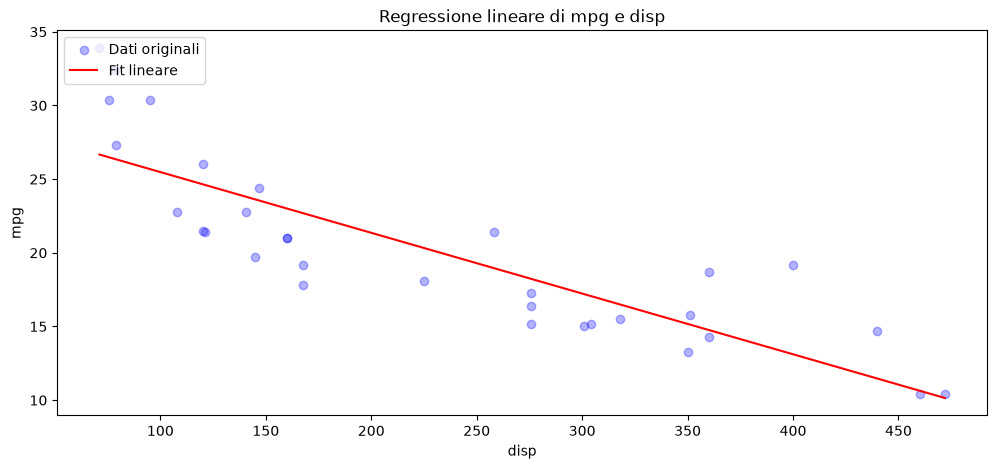

MAE: 2.6054734857723663
RMSE: 3.148207274000279


In [23]:
# Definisco le coordinate x e y
y = df['mpg']
x = df['disp']

# Definisco il modello lineare
def linear(x, a, b):
    return a * x + b 

# Calcolo dei parametri
params, _ = sp.optimize.curve_fit(linear, x, y)
a, b = params

# Predizione
y_pred = linear(x, a, b)

# Print dei parametri
print(f'Parametro (a): {a}')
print(f'Parametro (b): {b}')

# Creo lo scatter
plt.figure(figsize=(12, 5))
plt.scatter(x, y, alpha=0.3, label='Dati originali',color='blue')

# Plot
x_plot = np.linspace(x.min(), x.max(), 100)
y_plot = linear(x_plot, a, b)

plt.plot(x_plot, y_plot, label='Fit lineare', color='red')

plt.title('Regressione lineare di mpg e disp')
plt.xlabel('disp')
plt.ylabel('mpg')
plt.legend(loc='upper left')

plt.show()

print(f'MAE: {calculate_mae(y, y_pred)}')
print(f'RMSE: {calculate_rmse(y, y_pred)}')